In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/krupalpatel07/bank-of-america-daily-historical-data/bofa.csv


In [13]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.style.use('default')
sns.set_style("whitegrid")

import plotly.io as pio

pio.renderers.default = 'iframe'

In [3]:
# =====================================================
# 2. LOAD DATA
# =====================================================
file_path = "/kaggle/input/datasets/krupalpatel07/bank-of-america-daily-historical-data/bofa.csv"
df = pd.read_csv(file_path)

In [4]:
# =====================================================
# 3. PREPROCESSING
# =====================================================
df.columns = [col.lower() for col in df.columns]
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

In [5]:
# =====================================================
# 4. HTML
# =====================================================
from IPython.display import display, HTML

def luxury_header(text):
    display(HTML(f"""
    <div style="
        background: linear-gradient(90deg, #fdfcfb, #e2d1c3);
        padding: 20px;
        border-radius: 12px;
        border: 1px solid #d4af37;
        margin-top:20px;
    ">
        <h1 style="color:#b8962e; text-align:center; font-family:Georgia;">
            {text}
        </h1>
    </div>
    """))

luxury_header("📊 Price Structure Overview")


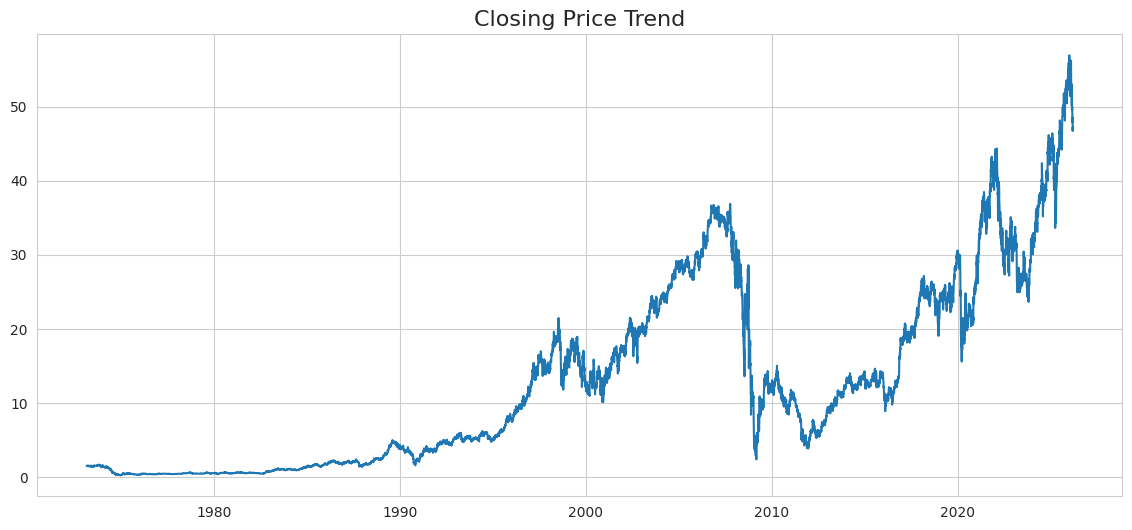

In [6]:
# =====================================================
# 5. CLEAN PRICE VISUAL
# =====================================================
plt.figure(figsize=(14,6))
plt.plot(df['close'])
plt.title("Closing Price Trend", fontsize=16)
plt.show()

In [14]:
# =====================================================
# 6. MARKET MICROSTRUCTURE ANALYSIS
# =====================================================
luxury_header("📉 Intraday Spread & Efficiency")

# High-Low Spread
df['spread'] = df['high'] - df['low']

# Efficiency Ratio
df['efficiency'] = abs(df['close'] - df['open']) / (df['high'] - df['low'])

fig = px.line(df, y='spread', title="Daily Spread")
fig.show()

In [8]:
# =====================================================
# 7. VOLUME PRESSURE ANALYSIS
# =====================================================
luxury_header("📦 Volume Pressure Zones")

# Volume Weighted Price Proxy
df['vwap_proxy'] = (df['close'] * df['volume']).cumsum() / df['volume'].cumsum()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['close'], name='Close'))
fig.add_trace(go.Scatter(x=df.index, y=df['vwap_proxy'], name='VWAP Proxy'))
fig.show()


In [9]:
# =====================================================
# 8. ALPHA FACTOR ENGINEERING
# =====================================================
luxury_header("🧠 Alpha Signal Engineering")

# Momentum
df['momentum'] = df['close'].pct_change(10)

# Mean Reversion
df['zscore'] = (df['close'] - df['close'].rolling(20).mean()) / df['close'].rolling(20).std()

fig = px.scatter(df, x='momentum', y='zscore')
fig.show()

R2 Score: -3.3693504709722717


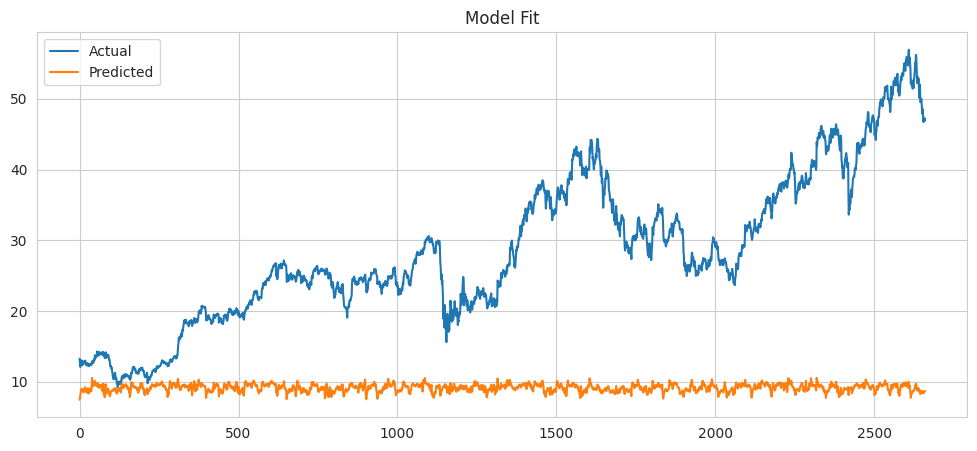

In [10]:
# =====================================================
# 9. LINEAR MODEL (ML)
# =====================================================
luxury_header("📐 Linear Alpha Model")

# Prepare data
df = df.dropna()
X = df[['momentum','zscore']]
y = df['close']

# Split
split = int(len(df)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Model
model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("R2 Score:", r2_score(y_test, preds))

# Plot
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title("Model Fit")
plt.show()

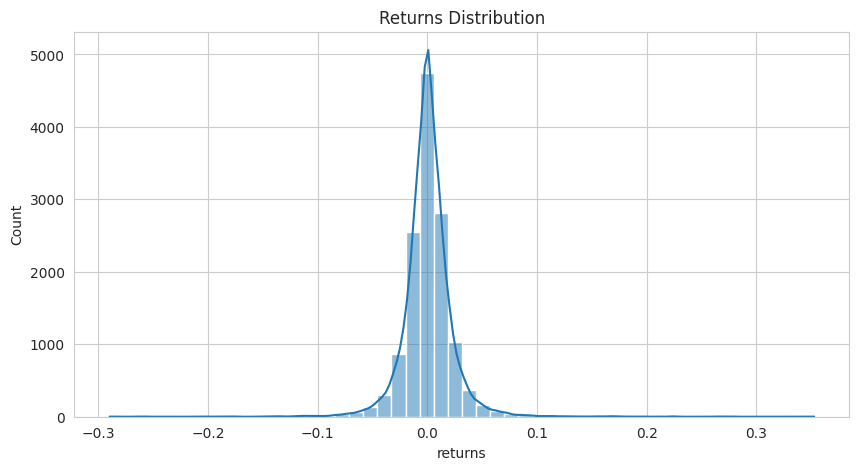

In [11]:
# =====================================================
# 10. DISTRIBUTION ANALYSIS
# =====================================================
luxury_header("📊 Return Distribution (Risk View)")

df['returns'] = df['close'].pct_change()

plt.figure(figsize=(10,5))
sns.histplot(df['returns'], bins=50, kde=True)
plt.title("Returns Distribution")
plt.show()


In [12]:
# =====================================================
# 11. FINAL INSIGHTS
# =====================================================
luxury_header("📌 Institutional Insights")

print("""
1. Spread expansion indicates volatility spikes.
2. VWAP proxy helps identify institutional accumulation.
3. Momentum + mean reversion together create alpha signals.
4. Linear model provides interpretable structure.
""")

# =====================================================
# END
# =====================================================


1. Spread expansion indicates volatility spikes.
2. VWAP proxy helps identify institutional accumulation.
3. Momentum + mean reversion together create alpha signals.
4. Linear model provides interpretable structure.

